In [5]:
import pandas as pd

df = pd.read_csv("C:\\Users\\annej\\Downloads\\AirQualityUCI.csv")

### To know the dataset

In [6]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10-03-2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10-03-2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10-03-2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10-03-2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10-03-2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


In [8]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='str')

In [9]:
df.shape

(9471, 17)

### Replace -200 with nan

In [10]:
print((df==-200).sum(axis=0))

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Unnamed: 15         0
Unnamed: 16         0
dtype: int64


In [15]:
import numpy as np
df = df.replace(-200, np.nan, inplace=True)

In [16]:
print(df.isnull().sum())

Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


### Visualize missing-value patterns using a heatmap and a bar chart showing missing percentage per column.

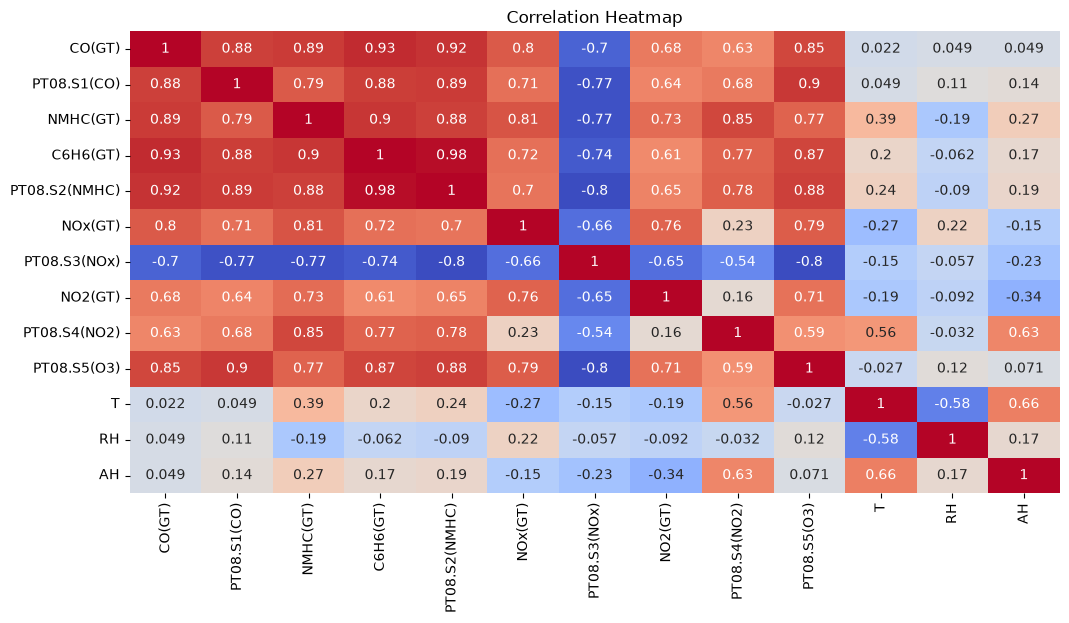

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
corr = df[['CO(GT)','PT08.S1(CO)','NMHC(GT)','C6H6(GT)',
           'PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)',
           'NO2(GT)','PT08.S4(NO2)','PT08.S5(O3)',
           'T','RH','AH']].corr()
sns.heatmap(corr, cbar=False, cmap='coolwarm',annot=True)
plt.title('Correlation Heatmap')
plt.show()

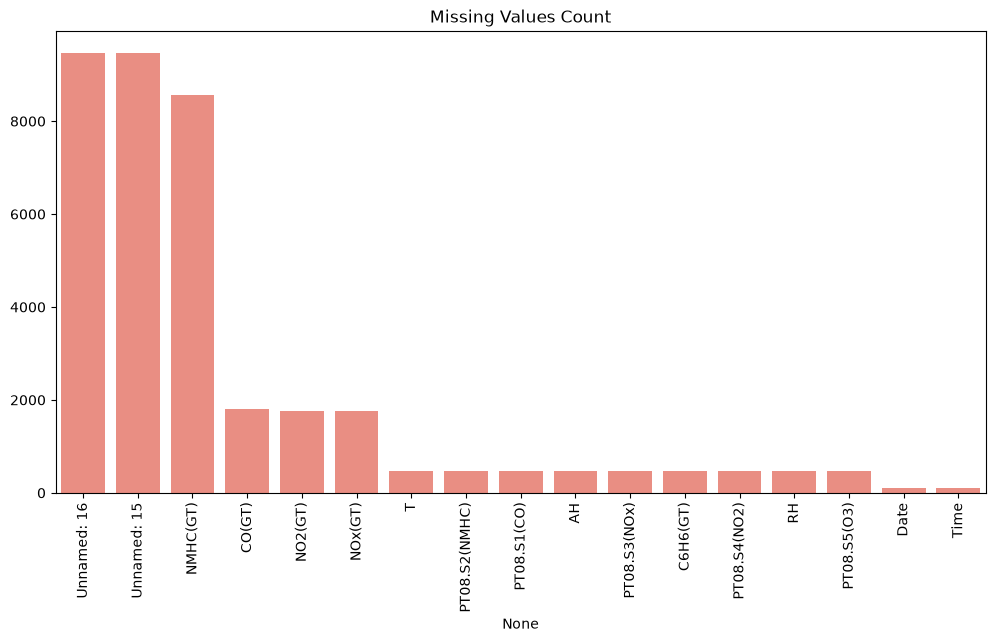

In [29]:
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing.index, y=missing.values, color='salmon')
plt.xticks(rotation=90)
plt.title('Missing Values Count')
plt.show()

### Apply means imputation on numerical columns with <10% missing values.

In [33]:
import numpy as np

nums_col = df.select_dtypes(include=[np.number]).columns

for col in nums_col:
    missing_percentage = df[col].isnull().sum() * 100 / len(df)
    if missing_percentage > 10:
        df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

Date              114
Time              114
CO(GT)              0
PT08.S1(CO)       480
NMHC(GT)            0
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)             0
PT08.S3(NOx)      480
NO2(GT)             0
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


### Apply median imputation on columns with 10–40% missing values to handle skewed distributions.

In [34]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100
    if 10 <= missing_percent <= 40:
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

Date              114
Time              114
CO(GT)              0
PT08.S1(CO)       480
NMHC(GT)            0
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)             0
PT08.S3(NOx)      480
NO2(GT)             0
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


### Verify no missing values remain using isnull().sum(). Display the before/after summary table

In [36]:
before = df.isnull().sum()

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    missing_percent = (df[col].isnull().sum() / len(df)) * 100
    if 10 <= missing_percent <= 40:
        df[col] = df[col].fillna(df[col].median())

after = df.isnull().sum()

print(pd.DataFrame({"Before": before, "After": after}))

               Before  After
Date              114    114
Time              114    114
CO(GT)              0      0
PT08.S1(CO)       480    480
NMHC(GT)            0      0
C6H6(GT)          480    480
PT08.S2(NMHC)     480    480
NOx(GT)             0      0
PT08.S3(NOx)      480    480
NO2(GT)             0      0
PT08.S4(NO2)      480    480
PT08.S5(O3)       480    480
T                 480    480
RH                480    480
AH                480    480
Unnamed: 15      9471   9471
Unnamed: 16      9471   9471


### Plot the distribution of 'CO(GT)' before and after imputation to confirm minimal distributional shift.

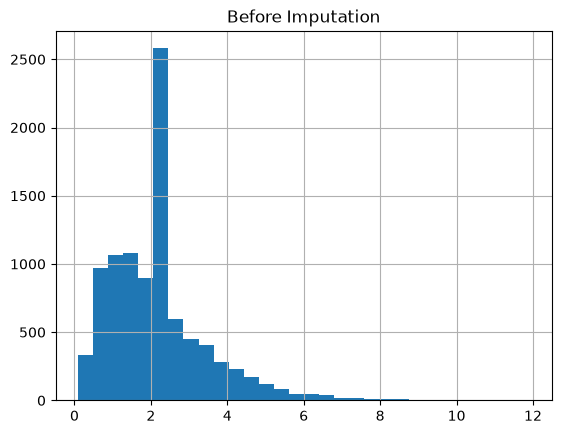

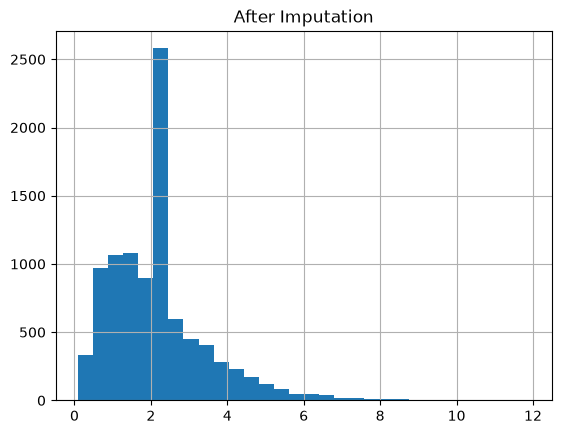

In [38]:
before = df["CO(GT)"].copy()

before.hist(bins=30)
plt.title("Before Imputation")
plt.show()

df["CO(GT)"] = df["CO(GT)"].fillna(df["CO(GT)"].median())

df["CO(GT)"].hist(bins=30)
plt.title("After Imputation")
plt.show()